In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from scipy.ndimage import uniform_filter

# Set default plot size for the notebook
plt.rcParams['figure.figsize'] = (15, 5)

In [2]:
def heaviside(phi, eps=1.0):
    """Regularized Heaviside function."""
    return 0.5 * (1 + (2 / np.pi) * np.arctan(phi / eps))

def dirac(phi, eps=1.0):
    """Regularized Dirac Delta function."""
    return (1 / np.pi) * (eps / (eps**2 + phi**2))

def apply_neumann_bc(phi):
    """Applies Neumann boundary conditions to prevent edge artifacts."""
    phi[0, :] = phi[1, :]
    phi[-1, :] = phi[-2, :]
    phi[:, 0] = phi[:, 1]
    phi[:, -1] = phi[:, -2]
    return phi

def manual_curvature(phi):
    """
    Computes the curvature of the level set function manually using 
    central finite differences, replacing np.gradient().
    axis=0 is y (rows), axis=1 is x (cols).
    """
    # 1st order derivatives
    phi_y = (np.roll(phi, -1, axis=0) - np.roll(phi, 1, axis=0)) / 2.0
    phi_x = (np.roll(phi, -1, axis=1) - np.roll(phi, 1, axis=1)) / 2.0
    
    # 2nd order derivatives
    phi_yy = np.roll(phi, -1, axis=0) - 2*phi + np.roll(phi, 1, axis=0)
    phi_xx = np.roll(phi, -1, axis=1) - 2*phi + np.roll(phi, 1, axis=1)
    
    # Mixed derivative
    phi_xy = (np.roll(np.roll(phi, -1, axis=0), -1, axis=1) - 
              np.roll(np.roll(phi, -1, axis=0), 1, axis=1) - 
              np.roll(np.roll(phi, 1, axis=0), -1, axis=1) + 
              np.roll(np.roll(phi, 1, axis=0), 1, axis=1)) / 4.0
    
    # Curvature calculation: div(grad(phi) / |grad(phi)|)
    mag_sq = phi_x**2 + phi_y**2 + 1e-8
    curvature = (phi_xx * phi_y**2 - 2 * phi_x * phi_y * phi_xy + phi_yy * phi_x**2) / (mag_sq**1.5)
    
    return curvature

In [3]:
# Load image and convert to float32
img_raw = cv2.imread('mri.png')
if img_raw is None:
    print("Error: Image not found. Check the file path.")
else:
    img = cv2.cvtColor(img_raw, cv2.COLOR_BGR2GRAY)
    I = img.astype(np.float32)
    print("Image loaded successfully. Shape:", I.shape)

Image loaded successfully. Shape: (256, 256)


In [5]:
def chan_vese(I, iters=300, mu=0.2, dt=0.5, eps=1.0):
    # Initialize level set
    phi = np.ones_like(I)
    phi[20:-20, 20:-20] = -1

    for i in range(iters):
        phi = apply_neumann_bc(phi)
        
        H = heaviside(phi, eps)
        delta_h = dirac(phi, eps)
        
        # Global means
        c_p = np.sum(I * H) / (np.sum(H) + 1e-8)
        c_n = np.sum(I * (1 - H)) / (np.sum(1 - H) + 1e-8)

        # Force and Update
        curvature = manual_curvature(phi)
        force = - (I - c_p)**2 + (I - c_n)**2
        
        phi += dt * delta_h * (mu * curvature + force)

        # Re-initialization step to keep phi stable
        if i % 10 == 0:
            phi = np.sign(phi)

    return phi

print("Running Chan-Vese...")
phi_cv = chan_vese(I)

Running Chan-Vese...


In [6]:
def local_active_contour(I, iters=300, mu=0.2, radius=9, dt=0.5, eps=1.0):
    phi = np.ones_like(I)
    phi[20:-20, 20:-20] = -1

    kernel_size = radius * 2 + 1

    for i in range(iters):
        phi = apply_neumann_bc(phi)
        
        H = heaviside(phi, eps)
        delta_h = dirac(phi, eps)

        # Local means using uniform (box) filter
        num_p = uniform_filter(I * H, size=kernel_size)
        den_p = uniform_filter(H, size=kernel_size)
        m_p = num_p / (den_p + 1e-8)

        num_n = uniform_filter(I * (1 - H), size=kernel_size)
        den_n = uniform_filter(1 - H, size=kernel_size)
        m_n = num_n / (den_n + 1e-8)

        # Force and Update
        curvature = manual_curvature(phi)
        local_force = 2 * (m_p - m_n) * (I - (m_p + m_n) / 2.0)
        
        phi += dt * delta_h * (mu * curvature + local_force)

        if i % 10 == 0:
            phi = np.sign(phi)

    return phi

print("Running Local Active Contour...")
phi_local = local_active_contour(I)

Running Local Active Contour...


In [10]:
def proposed_hybrid_active_contour(I, iters=300, mu=0.2, radius=9, tau=0.1, dt=0.5, eps=1.0):
    phi = np.ones_like(I)
    phi[20:-20, 20:-20] = -1

    kernel_size = radius * 2 + 1

    for i in range(iters):
        phi = apply_neumann_bc(phi)
        
        H = heaviside(phi, eps)
        delta_h = dirac(phi, eps)

        # Adaptive weight calculation
        dist = np.abs(phi)
        norm_dist = (dist / (np.max(dist) + 1e-8)) * 2.58
        omega = (1 / np.sqrt(2 * np.pi)) * np.exp(-0.5 * norm_dist**2)

        # Global means (weighted)
        c_p = np.sum(omega * I * H) / (np.sum(omega * H) + 1e-8)
        c_n = np.sum(omega * I * (1 - H)) / (np.sum(omega * (1 - H)) + 1e-8)

        # Local means
        m_p = uniform_filter(H * I, size=kernel_size) / (uniform_filter(H, size=kernel_size) + 1e-8)
        m_n = uniform_filter((1 - H) * I, size=kernel_size) / (uniform_filter(1 - H, size=kernel_size) + 1e-8)
        
        # Energy terms
        local_threshold = (m_p + m_n) / 2.0
        force = 2 * omega * (c_p - c_n) * (I - local_threshold)

        # Force and Update
        curvature = manual_curvature(phi)
        
        # CORRECTED LINE:
        phi += dt * (tau + delta_h * (mu * curvature + force))

        if i % 10 == 0:
            phi = np.sign(phi)
    
    return phi

print("Running Proposed Hybrid...")
phi_proposed = proposed_hybrid_active_contour(I)

Running Proposed Hybrid...


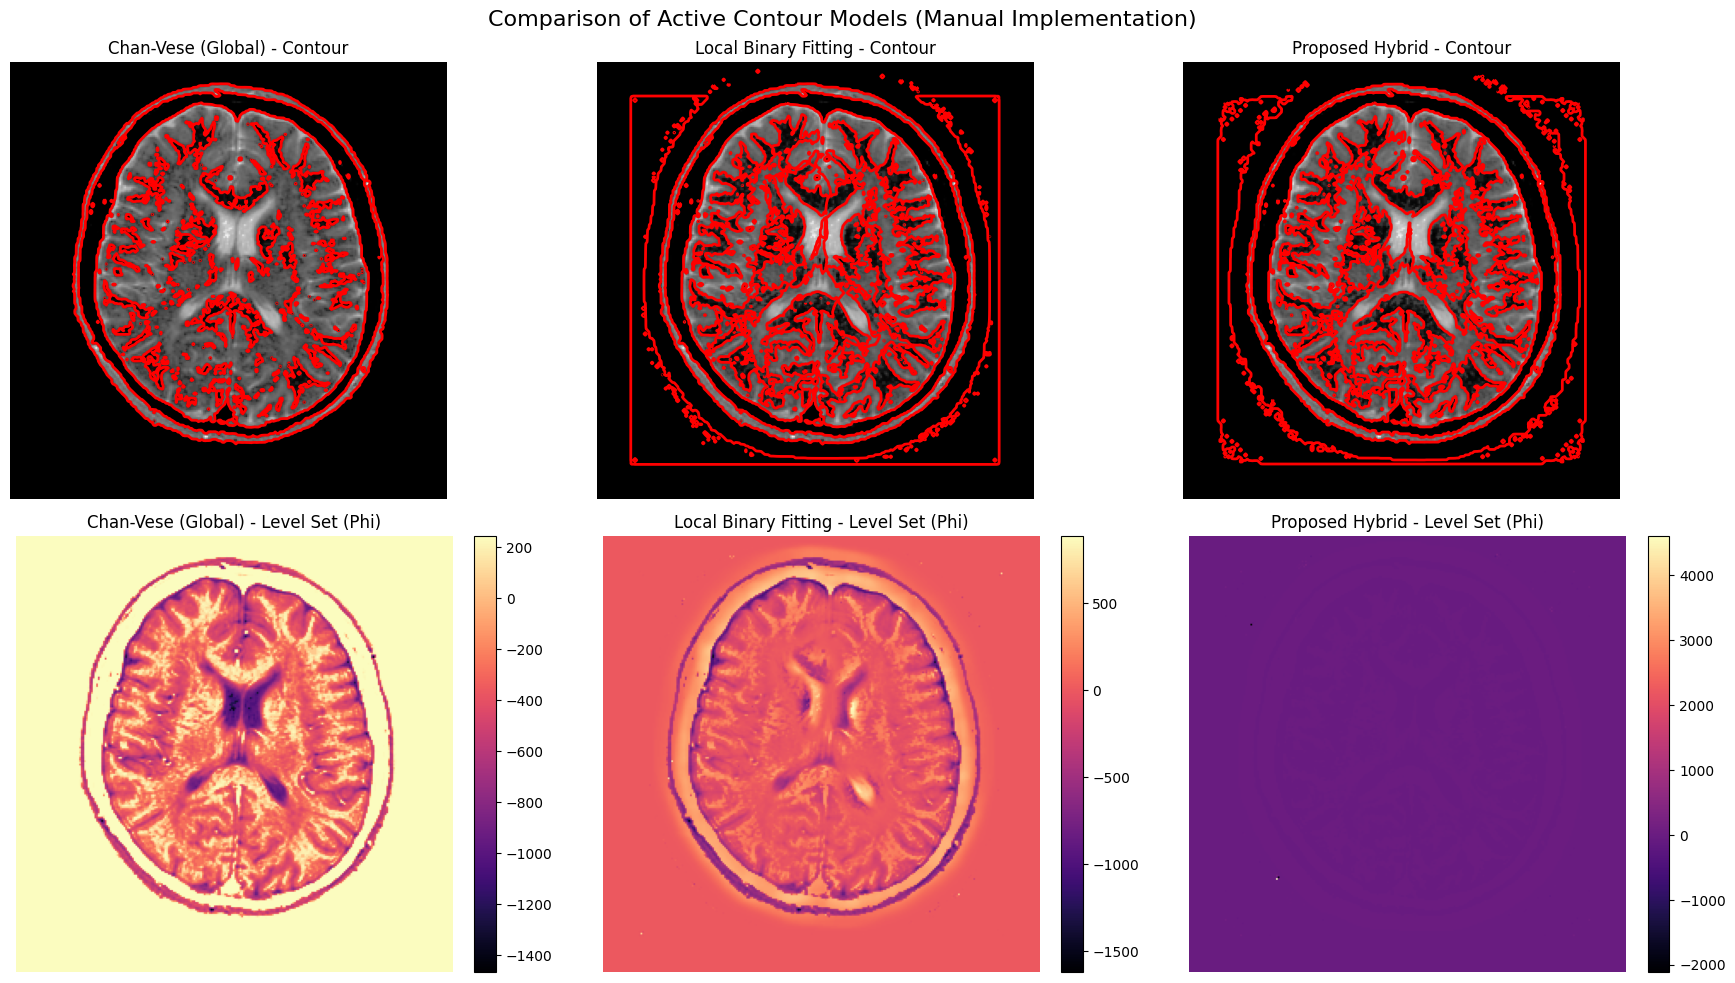

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Comparison of Active Contour Models (Manual Implementation)", fontsize=16)

titles = ["Chan-Vese (Global)", "Local Binary Fitting", "Proposed Hybrid"]
phis = [phi_cv, phi_local, phi_proposed]

for i, (title, phi_result) in enumerate(zip(titles, phis)):
    # Top Row: Contours over Original Image
    axes[0, i].imshow(img, cmap='gray')
    axes[0, i].contour(phi_result, [0], colors='r', linewidths=2)
    axes[0, i].set_title(f"{title} - Contour")
    axes[0, i].axis('off')
    
    # Bottom Row: The Level Set Function (Phi)
    im = axes[1, i].imshow(phi_result, cmap='magma')
    axes[1, i].set_title(f"{title} - Level Set (Phi)")
    axes[1, i].axis('off')
    fig.colorbar(im, ax=axes[1, i], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()